# 1. NOTEARS・CAREFL・CFGの統合モジュールの実装

## 1.1 causal_pipeline.pyの動作確認

### yamlファイルのロード

In [1]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [12]:
from pathlib import Path
from pipeline.utils import dict2namespace
import yaml


config_path = Path("config/config_all.yaml")
with open(config_path, "r") as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
config = dict2namespace(config_raw)

In [3]:
config.diffusion.unet

Namespace(ch_mul=[1, 2, 4], cond_type='add', droprate=0.0, num_groups=16, num_res_blocks=1, use_attn=False)

### CausalPipelineの初期化

In [6]:
from pipeline.causal_pipeline import CausalPipeline

pipeline = CausalPipeline(config)

### run_causal_discoveryの動作確認

In [10]:
from notears.utils import simulate_dag, simulate_parameter, simulate_linear_sem, is_dag
import torch

n = 1024
d = 10
s0 = 10
graph_type = 'ER'
B_true = simulate_dag(d, s0, graph_type)
assert is_dag(B_true)
W = simulate_parameter(B_true)
X = simulate_linear_sem(W, n, 'gauss')

In [11]:
B_est = pipeline.run_causal_discovery(X)
assert is_dag(B_est)

Running causal discovery for meta-data


### train_meta_causal_modelの動作確認

In [12]:
carefl =pipeline.train_meta_causal_model(X, B_est)

Training meta-causal model


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:51<00:00,  3.85it/s]


### intervene_genereteの動作確認

In [3]:
# Morpho-MNISTデータのロード

from dataset.morphomnist import load_morphomnist_like

dataset_dir = "/home/hashikami/datadrive/MorphoMNIST"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
metrics = metrics_df.to_numpy()


/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
metrics_df.head()

,thickness,intensity
index,,
0,2.398951,162.27393
1,2.789006,171.67532
2,2.655154,206.75359
3,2.852611,210.85230
4,1.750898,119.96817


In [8]:
# notearsの適用

from pipeline.causal_pipeline import CausalPipeline


pipeline = CausalPipeline(config)
B_est = pipeline.run_causal_discovery(metrics)
B_est

Running causal discovery for meta-data


array([[0, 1],
       [0, 0]], dtype=int32)

In [9]:
# careflの訓練

# ルートノードがガンマ分布のためscale_shift_base=Trueにしたほうがいいかも

carefl = pipeline.train_meta_causal_model(metrics, B_est)

Training meta-causal model


100%|██████████| 10/10 [00:43<00:00,  4.31s/it]


In [10]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_16/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-07-17_18.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)


In [11]:
# 介入分布からの生成

int_idx = [1]
int_val = [50.0]

pipeline.denoise_model = denoise_model
imgs = pipeline.intervene_generate(int_idx, int_val, num_samples=1, w=0.1)

Intervening and generating samples


sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step: 100%|██████████| 500/500 [00:10<00:00, 48.28it/s]


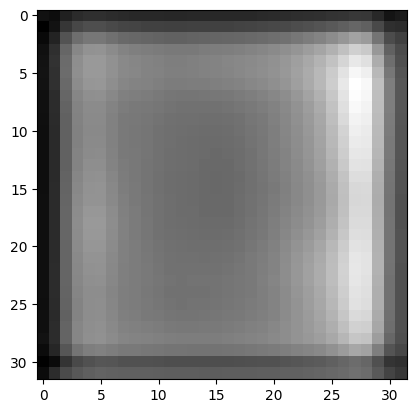

In [12]:
import matplotlib.pyplot as plt

plt.imshow(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')

### couterfactual_editingの動作確認

In [ ]:
# 反事実推論

import importlib

from pipeline import causal_pipeline
from pipeline.causal_pipeline import CausalPipeline

importlib.reload(causal_pipeline)

pipeline = CausalPipeline(config)
pipeline.carefl = carefl
pipeline.denoise_model = denoise_model



resources_dir = "/home/hashikami/projects/Diff/resources"
image = torch.load(os.path.join(resources_dir, "image9_size32_scale255.pt")) / 255.0
metrics = torch.load(os.path.join(resources_dir, "metrics_image9.pt"))


images_obs = image.unsqueeze(0).to(device)
x_obs = metrics.to(device)

cf_idx = [1]
cf_val = [50.0]

imgs = pipeline.counterfactual_editing(images_obs, x_obs, cf_idx, cf_val, w=0.1)





sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 50.20it/s]


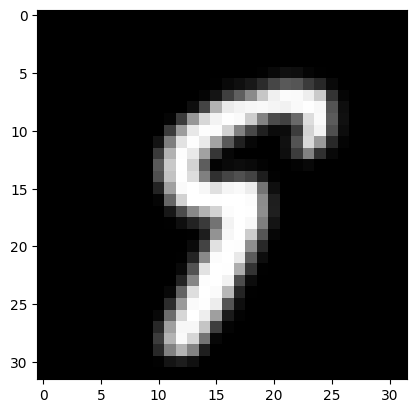

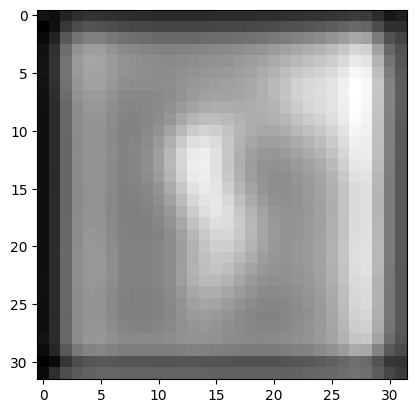

In [18]:
# images_obs[0]とimgs[-1][0]を可視化

import matplotlib.pyplot as plt


plt.imshow((images_obs[0] * 255.0).permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')
plt.show()

plt.imshow((imgs[-1][0] * 255.0).permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')
plt.show()